In [4]:
states=[i for i in range(101)]
p=[0.0 for i in range(101)]
mdp={i:{} for i in states}
p[100]=1.0
ph=0.4
pt=0.6
theta=1e-9

In [5]:
while True:
    delta=0
    pdash=p.copy()
    for s in range(1,100):
        pdash[s]=0.0
        for a in range(1,min(s,100-s)+1):
            pdash[s]=max(pdash[s],ph*p[s+a]+pt*p[s-a])
        delta=max(delta,abs(pdash[s]-p[s]))
    p=pdash
    if delta<theta:
        break
policy=[0]*101
for s in range(1,100):
    bestp=-1
    besta=0
    for a in range(1,min(s,100-s)+1):
        bla=ph*p[s+a]+pt*p[s-a]
        if bla>bestp:
            bestp=bla
            besta=a
    policy[s]=besta

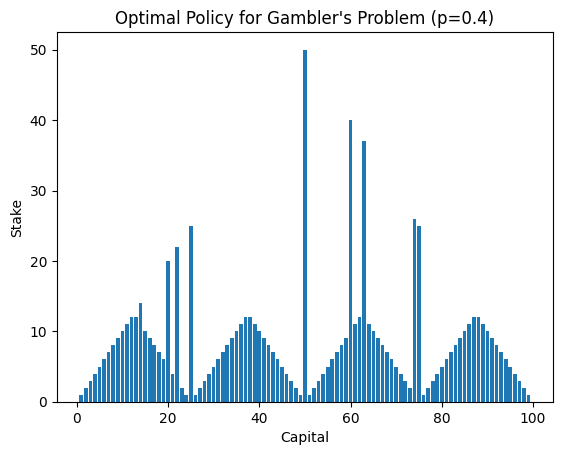

In [6]:
import matplotlib.pyplot as plt

plt.bar(range(1,100), policy[1:100])
plt.xlabel("Capital")
plt.ylabel("Stake")
plt.title("Optimal Policy for Gambler's Problem (p=0.4)")
plt.show()